In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Plotting function to compare between models (with & without reg (simple and combined preranks))

In [3]:
def compare_calibration_methods(df1, df2, label1="Without Regularization", label2="With Regularization", save_name=None):

    palette = {label1: '#E8505B', label2: '#4A90E2'}
    prerank_labels = {'pce_marginal': 'Marginal', 'pce_mean': 'Mean', 'pce_variance': 'Variance',
                      'pce_dependency': 'Dependency', 'pce_pca': 'PCA', 'pce_density': 'Density', 'pce_cdf': 'CDF'}
    order = [prerank_labels[c] for c in prerank_labels if c in df1.columns or c in df2.columns]

    def prep(df, lbl):
        cols = [c for c in prerank_labels if c in df.columns]
        long = df.melt(id_vars="data_name", value_vars=cols, var_name="prerank", value_name="score")
        long["source"] = lbl
        long["prerank"] = long["prerank"].map(prerank_labels)
        long = long.dropna(subset=["prerank"])
        long["prerank"] = pd.Categorical(long["prerank"], categories=order, ordered=True)
        return long

    to_plot = pd.concat([prep(df1, label1), prep(df2, label2)], ignore_index=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


    flierprops = dict(marker='o', markerfacecolor='#6C8EBF', markeredgecolor='#676B70', markersize=4, linestyle='none') #outliers


    # Panel 1: Box plot comparing distributions
    box = sns.boxplot(data=to_plot, x="prerank", y="score", hue="source", palette=palette, order=order,
                hue_order=[label1, label2], ax=ax1, linewidth=1.2, flierprops=flierprops)


    ax1.set_xlabel('Pre-rank Type', fontweight='bold', fontsize=11)
    ax1.set_ylabel('PCE Score', fontweight='bold', fontsize=11)
    ax1.set_title('(a) Distribution Across Datasets', loc='left', fontweight='bold', fontsize=12)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax1.legend(frameon=True, loc='upper left', edgecolor='gray', framealpha=0.95)

    # Panel 2: Mean reduction per prerank with error bars
    summary = to_plot.groupby(['prerank', 'source'], observed=True)['score'].agg(mean='mean', sem='sem').reset_index()
    mean_p = summary.pivot(index='prerank', columns='source', values='mean').reindex(order)
    sem_p = summary.pivot(index='prerank', columns='source', values='sem').reindex(order)
    reduction = (1 - mean_p[label2] / mean_p[label1]) * 100

    x = np.arange(len(order))
    width = 0.30
    offset = width / 2 + 0.02
    bar_kws = dict(width=width, alpha=0.9, edgecolor='white', linewidth=0.5,
                   error_kw={'linewidth': 1.2, 'capsize': 4})
    ax2.bar(x - offset, mean_p[label1], yerr=sem_p[label1], label=label1, color=palette[label1], **bar_kws)
    ax2.bar(x + offset, mean_p[label2], yerr=sem_p[label2], label=label2, color=palette[label2], **bar_kws)

    ax2.set_xlabel('Pre-rank Type', fontweight='bold', fontsize=11)
    ax2.set_ylabel('Mean PCE (± SEM)', fontweight='bold', fontsize=11)
    ax2.set_title('(b) Systematic Reduction', loc='left', fontweight='bold', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(order, rotation=30, ha='right')
    ax2.legend(frameon=True, loc='upper left', edgecolor='gray', framealpha=0.95)

    for ax in (ax1, ax2):
        ax.grid(axis='y', alpha=0.25, linestyle='--')
        ax.set_axisbelow(True)

    for i, (pct, val) in enumerate(zip(reduction, mean_p[label1])):
        if pd.notna(pct) and pct > 0:
            ax2.text(i, val + 0.01, f'−{pct:.0f}%', ha='center', va='bottom', fontsize=9,
                     fontweight='bold', color='#2c3e50')

    plt.tight_layout()
    if save_name:
        for ext in ['.pdf', '.png']:
            plt.savefig(f'figures/paper/{save_name}{ext}', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Average calibration error reduction: {reduction[reduction > 0].mean():.1f}%")


### Load trained models with different reg

In [4]:
def load_metrics(path):
    df = pd.read_csv(path)
    avg = df.groupby(['data_name'], sort=False).mean(numeric_only=True).reset_index()
    drop_cols = ['seed', 'train_prerank', 'train_time_seconds', 'epochs_trained', 'best_epoch']
    avg = avg.drop(columns=drop_cols, errors='ignore')
    return avg

avg_df_with_density_reg = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=density.csv')
avg_df_with_marginal_reg = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=marginal.csv')
avg_df_with_mean_reg = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=mean.csv')
avg_df_with_variance_reg = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=variance.csv')
avg_df_with_pca_reg = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=pca.csv')

avg_df_without_reg = load_metrics('csv-files/metrics-from-model-without-reg.csv')

# avg_df_with_pca_and_ALL = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=PCA+Mean+Variance+Dependency+Density+CDF.csv')
# avg_df_with_marginal_and_ALL = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=Marginal+Mean+Variance+Dependency+Density+CDF.csv')


# df_hdr = load_metrics('csv-files/metrics-hdr-wide.csv')

In [4]:
def compare_training_time_and_calibration(pca_all_path, marginal_all_path):
    def summarize(path, label):
        df = pd.read_csv(path)
        pce_cols = [c for c in df.columns if c.startswith('pce_')]
        if not pce_cols:
            raise ValueError(f"No PCE columns found in {path}")
        return (
            df.assign(pce_avg=df[pce_cols].mean(axis=1))
              .groupby('data_name', sort=False)[['train_time_seconds', 'pce_avg', 'nll', 'energy']]
              .mean()
              .rename(columns={
                  'train_time_seconds': f'train_time_{label}',
                  'pce_avg': f'pce_avg_{label}',
                  'nll': f'nll_{label}',
                  'energy': f'energy_{label}'
              })
        )

    pca_all = summarize(pca_all_path, 'pca_all')
    marginal_all = summarize(marginal_all_path, 'marginal_all')
    summary = pca_all.join(marginal_all)

    overall = summary.mean().to_dict()
    print(
        f"Mean train time (s): PCA+ALL={overall['train_time_pca_all']:.1f}, "
        f"Marginal+ALL={overall['train_time_marginal_all']:.1f}"
    )
    print(
        f"Mean PCE (lower is better): PCA+ALL={overall['pce_avg_pca_all']:.4f}, "
        f"Marginal+ALL={overall['pce_avg_marginal_all']:.4f}"
    )

    summary['faster'] = np.where(
        summary['train_time_pca_all'] < summary['train_time_marginal_all'],
        'PCA+ALL',
        'Marginal+ALL'
    )
    summary['better_calibration'] = np.where(
        summary['pce_avg_pca_all'] < summary['pce_avg_marginal_all'],
        'PCA+ALL',
        'Marginal+ALL'
    )

    summary['lower_energy'] = np.where(
        summary['energy_pca_all'] < summary['energy_marginal_all'],
        'PCA+ALL',
        'Marginal+ALL'
    )
    summary['lower_nll'] = np.where(
        summary['nll_pca_all'] < summary['nll_marginal_all'],
        'PCA+ALL',
        'Marginal+ALL'
    )

    return summary.sort_values('train_time_pca_all')

train_time_vs_calibration = compare_training_time_and_calibration(
    'csv-files/metrics-from-model-trained-on-train_prerank=PCA+Mean+Variance+Dependency+Density+CDF.csv',
    'csv-files/metrics-from-model-trained-on-train_prerank=Marginal+Mean+Variance+Dependency+Density+CDF.csv'
)
train_time_vs_calibration

Mean train time (s): PCA+ALL=5654.2, Marginal+ALL=5343.4
Mean PCE (lower is better): PCA+ALL=0.0958, Marginal+ALL=0.0949


,train_time_pca_all,pce_avg_pca_all,nll_pca_all,energy_pca_all,train_time_marginal_all,pce_avg_marginal_all,nll_marginal_all,energy_marginal_all,faster,better_calibration,lower_energy,lower_nll
data_name,,,,,,,,,,,,
wq,160.658071,0.195534,46.324888,2.603535,163.125900,0.198645,102.391426,2.605655,PCA+ALL,PCA+ALL,PCA+ALL,PCA+ALL
scpf,523.088091,0.134141,-4.963760,0.469971,486.689320,0.136070,-4.534003,0.471066,Marginal+ALL,PCA+ALL,PCA+ALL,PCA+ALL
wage,543.314247,0.153641,0.432564,0.702509,547.508619,0.150159,0.432037,0.699675,PCA+ALL,Marginal+ALL,Marginal+ALL,Marginal+ALL
households,848.449051,0.089345,3.161811,0.923041,869.221792,0.087244,3.187130,0.925472,PCA+ALL,Marginal+ALL,PCA+ALL,PCA+ALL
meps_21,931.995279,0.070255,-1.739870,0.400374,1297.844122,0.069917,-1.956860,0.384990,PCA+ALL,Marginal+ALL,Marginal+ALL,Marginal+ALL
scm20d,947.819317,0.078602,8.398065,2.298145,781.767080,0.076718,8.537912,2.330112,Marginal+ALL,Marginal+ALL,PCA+ALL,PCA+ALL
meps_19,986.499701,0.073105,-1.924698,0.381411,1084.481315,0.075021,-1.999812,0.372656,PCA+ALL,PCA+ALL,Marginal+ALL,Marginal+ALL
scm1d,1002.788687,0.072949,9.736595,2.083536,1285.702749,0.065745,7.439030,2.025877,PCA+ALL,Marginal+ALL,Marginal+ALL,Marginal+ALL
meps_20,1140.477082,0.072510,-1.835184,0.394809,1208.584169,0.065808,-1.835839,0.394187,PCA+ALL,Marginal+ALL,Marginal+ALL,Marginal+ALL


In [5]:
train_time_vs_calibration = compare_training_time_and_calibration(
    'csv-files/metrics-from-model-trained-on-train_prerank=pca.csv',
    'csv-files/metrics-from-model-trained-on-train_prerank=marginal.csv'
)
train_time_vs_calibration

Mean train time (s): PCA+ALL=528.3, Marginal+ALL=399.2
Mean PCE (lower is better): PCA+ALL=0.1111, Marginal+ALL=0.1112


,train_time_pca_all,pce_avg_pca_all,nll_pca_all,energy_pca_all,train_time_marginal_all,pce_avg_marginal_all,nll_marginal_all,energy_marginal_all,faster,better_calibration,lower_energy,lower_nll
data_name,,,,,,,,,,,,
wage,80.304620,0.156261,0.356589,0.704511,70.780202,0.157232,0.483787,0.706061,Marginal+ALL,PCA+ALL,PCA+ALL,PCA+ALL
wq,97.840470,0.197854,24.183617,2.593533,66.370645,0.199843,157.928785,2.600254,Marginal+ALL,PCA+ALL,PCA+ALL,PCA+ALL
scm20d,103.641046,0.080478,7.917306,2.326155,99.130553,0.079448,7.853069,2.293035,Marginal+ALL,Marginal+ALL,Marginal+ALL,Marginal+ALL
meps_19,126.711164,0.105991,-1.859618,0.383460,138.326145,0.111557,-2.014628,0.378096,PCA+ALL,PCA+ALL,Marginal+ALL,Marginal+ALL
scm1d,140.543909,0.065830,10.511229,2.031879,120.487591,0.069777,7.330140,1.986190,Marginal+ALL,PCA+ALL,Marginal+ALL,Marginal+ALL
ansur2,140.829478,0.103052,1.775327,0.537925,103.510637,0.097061,1.774644,0.535050,Marginal+ALL,Marginal+ALL,Marginal+ALL,Marginal+ALL
households,150.163734,0.093762,3.226198,0.923467,127.897000,0.093454,3.204606,0.928347,Marginal+ALL,Marginal+ALL,PCA+ALL,Marginal+ALL
meps_20,150.251837,0.107311,-1.808964,0.401423,135.550410,0.108779,-1.793894,0.400639,Marginal+ALL,PCA+ALL,Marginal+ALL,PCA+ALL
air,161.234096,0.106428,5.617477,1.399134,171.073229,0.107355,5.582314,1.399156,PCA+ALL,PCA+ALL,PCA+ALL,Marginal+ALL


### Transform metrics-hdr.csv to wide format (match prerank metrics CSVs)
- PCE values are pivoted into `pce_*` columns.
- NLL is constant per dataset; Energy varies by prerank, so choose a reduction strategy (mean or marginal).
- `seed` is filled with a fixed value and `mse` is left as NaN to match column layout.


In [ ]:
def hdr_to_wide(hdr_path, save_path=None, energy_strategy='mean', seed_value=0):
    hdr = pd.read_csv(hdr_path)
    pce_wide = hdr.pivot(index='data_name', columns='prerank', values='pce')
    pce_wide = pce_wide.add_prefix('pce_').reset_index()

    nll = hdr.groupby('data_name', sort=False)['nll'].first().reset_index()
    if energy_strategy == 'mean':
        energy = hdr.groupby('data_name', sort=False)['energy'].mean().reset_index()
    elif energy_strategy == 'marginal':
        energy = hdr[hdr['prerank'] == 'marginal'][['data_name', 'energy']]
    else:
        raise ValueError('energy_strategy must be mean or marginal')

    out = nll.merge(energy, on='data_name', how='left').merge(pce_wide, on='data_name', how='left')
    out['seed'] = seed_value
    out['mse'] = np.nan

    cols = [
        'data_name', 'seed', 'nll', 'energy',
        'pce_marginal', 'pce_mean', 'pce_variance', 'pce_dependency',
        'pce_pca', 'pce_density', 'pce_cdf', 'mse'
    ]
    out = out.reindex(columns=cols)

    if save_path:
        out.to_csv(save_path, index=False)
    return out
hdr_wide = hdr_to_wide(
    'metrics-hdr.csv',
    save_path='csv-files/metrics-hdr-wide.csv',
    energy_strategy='mean',
    seed_value=0,
)
hdr_wide.head()

In [18]:
def hdr_to_wide(hdr_path, save_path=None, energy_strategy='mean', seed_value=0):
    hdr = pd.read_csv(hdr_path)
    pce_wide = hdr.pivot(index='data_name', columns='prerank', values='pce')
    pce_wide = pce_wide.add_prefix('pce_').reset_index()

    nll = hdr.groupby('data_name', sort=False)['nll'].first().reset_index()
    if energy_strategy == 'mean':
        energy = hdr.groupby('data_name', sort=False)['energy'].mean().reset_index()
    elif energy_strategy == 'marginal':
        energy = hdr[hdr['prerank'] == 'marginal'][['data_name', 'energy']]
    else:
        raise ValueError('energy_strategy must be mean or marginal')

    out = nll.merge(energy, on='data_name', how='left').merge(pce_wide, on='data_name', how='left')
    out['seed'] = seed_value
    out['mse'] = np.nan

    cols = [
        'data_name', 'seed', 'nll', 'energy',
        'pce_marginal', 'pce_mean', 'pce_variance', 'pce_dependency',
        'pce_pca', 'pce_density', 'pce_cdf', 'mse'
    ]
    out = out.reindex(columns=cols)

    if save_path:
        out.to_csv(save_path, index=False)
    return out

hdr_wide = hdr_to_wide(
    'metrics-hdr.csv',
    save_path='csv-files/metrics-hdr-wide.csv',
    energy_strategy='mean',
    seed_value=0,
)
hdr_wide.head()

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,households,0,3.286228,0.945249,0.025537,0.018683,0.020806,0.019679,0.020114,0.018341,0.027575,NaN
1,air,0,5.685531,1.420570,0.028872,0.025382,0.024479,0.026395,0.026400,0.022548,0.039721,NaN
2,births1,0,1.130322,0.696401,0.033125,0.033288,0.032594,0.027027,0.027548,0.023558,0.032406,NaN
3,births2,0,-4.219483,0.920412,0.118133,0.050848,0.085437,0.038354,0.057774,0.033606,0.043993,NaN
4,wage,0,0.635542,0.702100,0.046533,0.042628,0.028472,0.028729,0.042089,0.034068,0.045013,NaN


### Comparison lenses for 3-model + baseline analysis

In [5]:
PRERANK_LABELS = {
    'pce_marginal': 'Marginal',
    'pce_mean': 'Mean',
    'pce_variance': 'Variance',
    'pce_dependency': 'Dependency',
    'pce_pca': 'PCA',
    'pce_density': 'Density',
    'pce_cdf': 'CDF',
}

def align_on_common_data(model_frames):
    common = None
    for name, df in model_frames.items():
        names = set(df['data_name'].dropna().unique())
        common = names if common is None else common & names
    if not common:
        raise ValueError('No overlapping data_name values across model_frames.')
    return {name: df[df['data_name'].isin(common)].copy() for name, df in model_frames.items()}

def long_prerank_frame(model_frames, prerank_labels=PRERANK_LABELS):

    frames = []
    seen_labels = set()

    value_label_map = {k.replace('pce_', '').lower(): v for k, v in prerank_labels.items()}

    for name, df in model_frames.items():
        # Long format (e.g., HDR: data_name, prerank, pce)
        if {'data_name', 'prerank', 'pce'}.issubset(df.columns):
            long = df[['data_name', 'prerank', 'pce']].copy()
            long = long.rename(columns={'pce': 'score'})
            long['model'] = name
            long['prerank'] = (
                long['prerank']
                .astype(str)
                .str.replace('pce_', '', regex=False)
                .str.lower()
                .map(value_label_map)
            )
            long = long.dropna(subset=['prerank', 'score'])
            seen_labels.update(long['prerank'].unique().tolist())
            frames.append(long)
            continue

        # Wide format (default)
        cols = [c for c in prerank_labels if c in df.columns]
        if not cols:
            continue
        long = df.melt(id_vars='data_name', value_vars=cols, var_name='prerank', value_name='score')
        long['model'] = name
        long['prerank'] = long['prerank'].map(prerank_labels)
        long = long.dropna(subset=['prerank', 'score'])
        seen_labels.update(long['prerank'].unique().tolist())
        frames.append(long)

    if not frames:
        raise ValueError('No prerank columns found in model_frames (expected wide pce_* or long (data_name, prerank, pce)).')

    order = [prerank_labels[c] for c in prerank_labels if prerank_labels[c] in seen_labels]
    out = pd.concat(frames, ignore_index=True)
    out['prerank'] = pd.Categorical(out['prerank'], categories=order, ordered=True)
    return out

def plot_delta_vs_baseline(model_frames, baseline_label, save_name=None):

    aligned = align_on_common_data(model_frames)
    long = long_prerank_frame(aligned)
    base = long[long['model'] == baseline_label][['data_name', 'prerank', 'score']].rename(columns={'score': 'baseline_score'})
    merged = long.merge(base, on=['data_name', 'prerank'], how='inner')
    merged = merged[merged['model'] != baseline_label].copy()
    # merged['delta'] = merged['score'] - merged['baseline_score']
    # merged['rel_change_%'] = 100 * (1 - merged['score'] / merged['baseline_score'])

    order = list(long['prerank'].cat.categories)
    models = [m for m in model_frames.keys() if m != baseline_label]
    palette = dict(zip(models, sns.color_palette('Set2', n_colors=len(models))))

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(data=merged, x='prerank', y='score', hue='model', order=order, hue_order=models, palette=palette, ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Pre-rank Type', fontweight='bold', fontsize=11)
    ax.set_ylabel('PCE difference', fontweight='bold', fontsize=11)
    ax.set_title('PCE difference', loc='left', fontweight='bold', fontsize=12)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(frameon=True, loc='upper left', edgecolor='gray', framealpha=0.95)

    plt.tight_layout()
    if save_name:
        for ext in ['.pdf', '.png']:
            plt.savefig(f'figures/paper/{save_name}{ext}', dpi=300, bbox_inches='tight')
    plt.show()

    summary = merged.groupby(['model', 'prerank'], observed=True)['score'].median().unstack()
    return summary

In [6]:
def plot_delta_vs_baseline2(model_frames, baseline_label=None, save_name=None):
    """Plot PCE scores directly (no deltas), across all datasets.

    Aligns datasets across models, plots per-dataset PCE scores by prerank for
    every model (including the baseline if provided), and returns the long
    table of scores for inspection.
    """
    aligned = align_on_common_data(model_frames)
    long = long_prerank_frame(aligned)

    order = list(long['prerank'].cat.categories)
    models = list(model_frames.keys())
    palette = dict(zip(models, sns.color_palette('Set2', n_colors=len(models))))

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(
        data=long,
        x='prerank',
        y='score',
        hue='model',
        order=order,
        hue_order=models,
        palette=palette,
        ax=ax,
        fliersize=0,
    )
    sns.stripplot(
        data=long,
        x='prerank',
        y='score',
        hue='model',
        order=order,
        hue_order=models,
        palette=palette,
        ax=ax,
        dodge=True,
        alpha=0.55,
        linewidth=0.6,
        edgecolor='gray',
    )

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), frameon=True, loc='upper left', edgecolor='gray', framealpha=0.95)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Pre-rank Type', fontweight='bold', fontsize=11)
    ax.set_ylabel('PCE score', fontweight='bold', fontsize=11)
    ax.set_title('PCE scores per dataset', loc='left', fontweight='bold', fontsize=12)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    if save_name:
        for ext in ['.pdf', '.png']:
            plt.savefig(f'figures/paper/{save_name}{ext}', dpi=300, bbox_inches='tight')
    plt.show()

    return long[['data_name', 'model', 'prerank', 'score']]


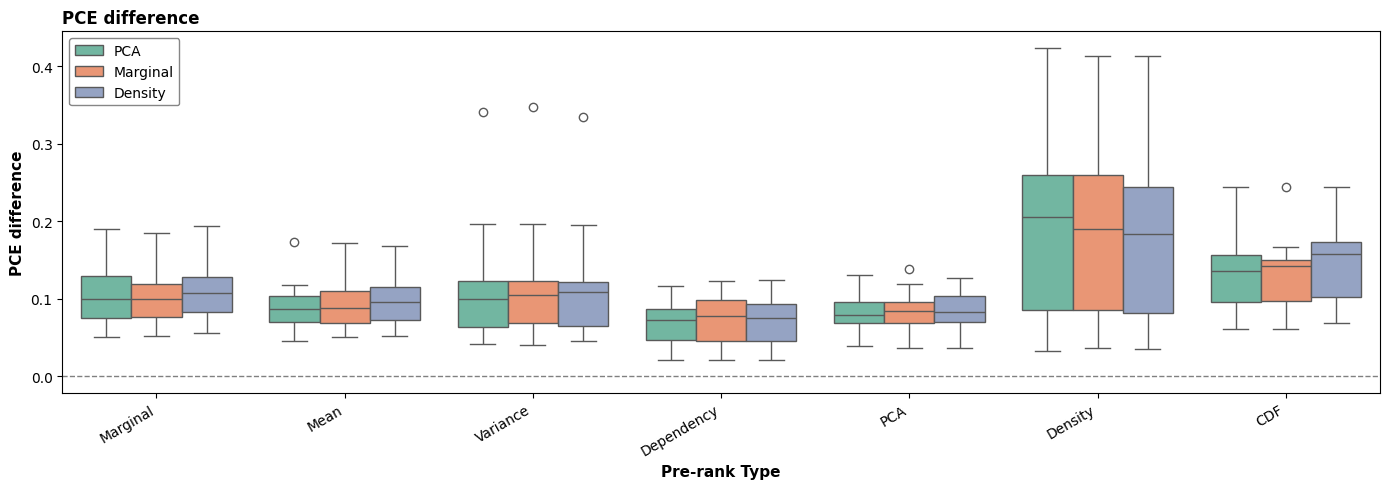

prerank,Marginal,Mean,Variance,Dependency,PCA,Density,CDF
model,,,,,,,
Density,0.107543,0.095446,0.109473,0.075143,0.082854,0.183958,0.158030
Marginal,0.100104,0.088817,0.105320,0.077527,0.083787,0.190357,0.142351
PCA,0.099982,0.087009,0.099810,0.072987,0.078769,0.205185,0.135299


In [7]:
model_frames = {
    'PCA': avg_df_with_pca_reg,
    'Marginal': avg_df_with_marginal_reg,
    'Density': avg_df_with_density_reg,
    'Without Regularization': avg_df_without_reg,
}

delta_summary = plot_delta_vs_baseline(model_frames, baseline_label='Without Regularization', save_name='TEST')
delta_summary

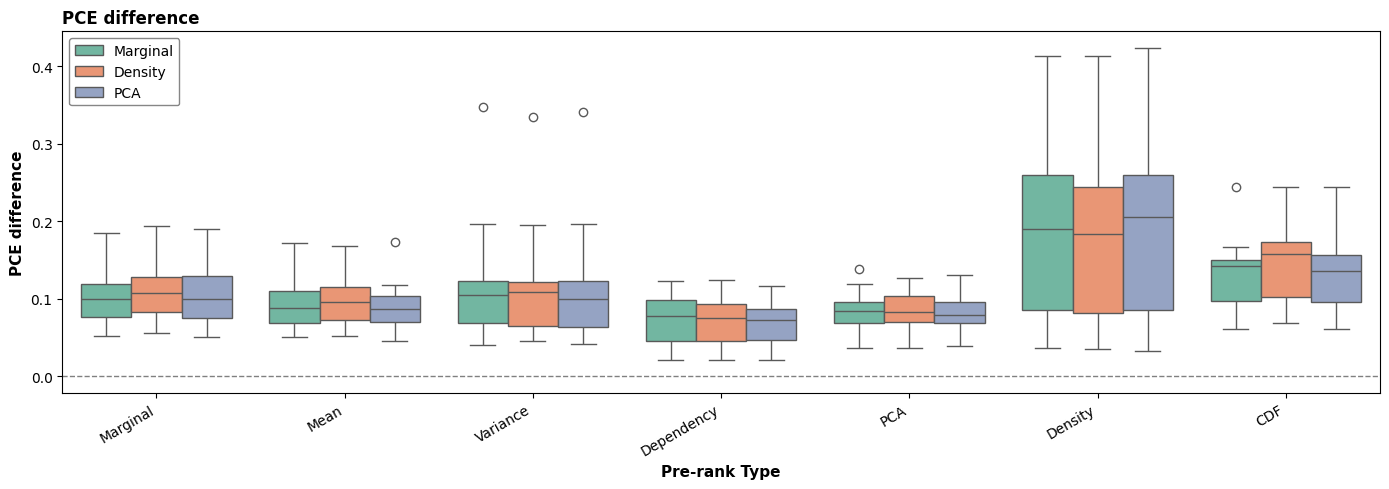

prerank,Marginal,Mean,Variance,Dependency,PCA,Density,CDF
model,,,,,,,
Density,0.107543,0.095446,0.109473,0.075143,0.082854,0.183958,0.158030
Marginal,0.100104,0.088817,0.105320,0.077527,0.083787,0.190357,0.142351
PCA,0.099982,0.087009,0.099810,0.072987,0.078769,0.205185,0.135299


In [8]:
model_frames = {
    'Without Regularization': avg_df_without_reg,
    'Marginal': avg_df_with_marginal_reg,
    'Density': avg_df_with_density_reg,
    'PCA': avg_df_with_pca_reg,
}

delta_summary = plot_delta_vs_baseline(model_frames, baseline_label='Without Regularization', save_name='TEST2')
delta_summary

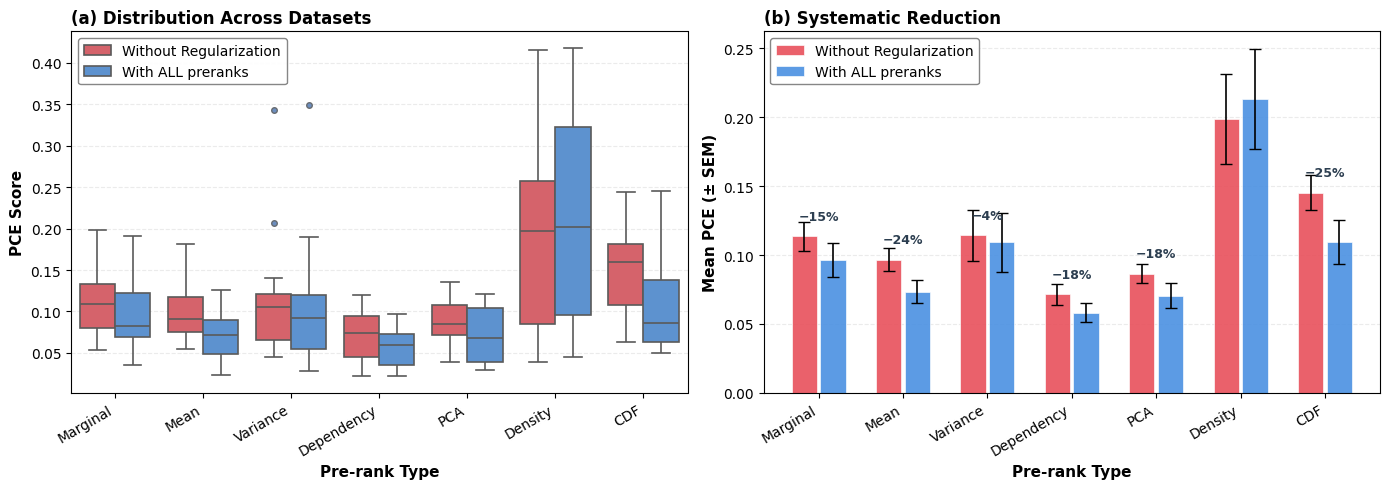

Average calibration error reduction: 17.6%


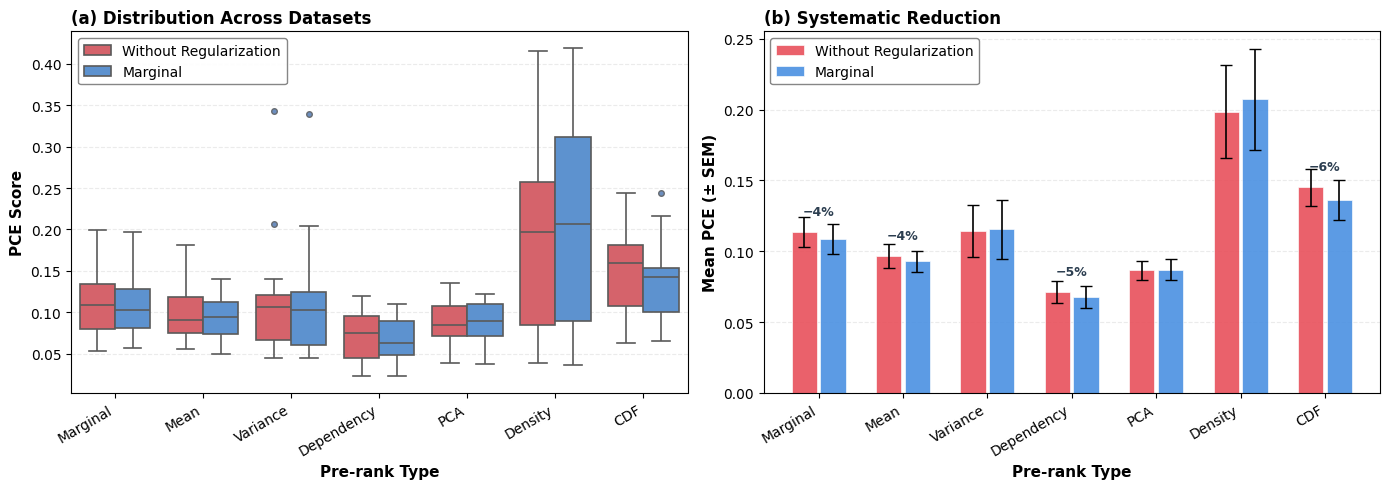

Average calibration error reduction: 4.9%


In [11]:
compare_calibration_methods(avg_df_without_reg, avg_df_combined_ALL, 'Without Regularization', 'With ALL preranks', 'comparison-fig-all-preranks-no-reg')
compare_calibration_methods(avg_df_without_reg, avg_df_with_simple_reg, 'Without Regularization','Marginal', 'comparison-fig-marginal-no-reg')

In [17]:
df_hdr = pd.read_csv('metrics-hdr.csv')
df_hdr

,data_name,prerank,pce,energy,nll
0,households,marginal,0.025537,0.946943,3.286228
1,households,mean,0.018683,0.946145,3.286228
2,households,variance,0.020806,0.942322,3.286228
3,households,dependency,0.019679,0.949163,3.286228
4,households,pca,0.020114,0.945214,3.286228
...,...,...,...,...,...
121,taxi,variance,0.025650,0.685726,1.675086
122,taxi,dependency,0.022429,0.684384,1.675086
123,taxi,pca,0.021144,0.685127,1.675086
124,taxi,density,0.020719,0.684548,1.675086
